# 04 · FIBO-based reasoning over HBIM

We merge the **FIBO excerpt** with the **HBIM** Account subject area and run an
**OWL RL** reasoner (`owlrl`). Because HBIM is aligned to FIBO, the FIBO axioms
flow into HBIM and the reasoner derives facts never stated in HBIM:

- **A.** class-level inferences – new superclasses for HBIM classes
- **B.** instance-level inferences – new types for HBIM individuals
- **C.** how this *improves* HBIM (enrich, completeness rules, equivalence bridges)
- **C.4** a consistency check that uses FIBO disjointness to catch a bad mapping

Reads the FIBO excerpt + `output/hbim_account.ttl`; writes
`output/hbim_account_inferred.ttl`.

In [1]:
import sys, json
from pathlib import Path

# Make ../src importable so we can reuse the shared paths + namespaces.
SRC = Path.cwd().parent / "src"
sys.path.insert(0, str(SRC))
from common import (COLLIBRA_EXPORT, EXTRACTED_FILE, MAPPING_FILE,
                    HBIM_TTL, HBIM_INFERRED_TTL, FIBO_EXCERPT, OUTPUT_DIR,
                    PREFIXES, bind_all,
                    CAA, FPAS, FSE, REL, CMNS_ID, CMNS_ORG, HBIM)
import pandas as pd
pd.set_option("display.max_colwidth", 60)
print("Project root:", SRC.parent)

Project root: C:\Users\marci\OneDrive\DEV\EDU\AIML\Graph ML\Ontology Engineering\Ontology Repository\FIBO\Ontology Mapping


In [2]:
from rdflib import Graph, RDF, RDFS, OWL, URIRef, BNode
from rdflib.namespace import SKOS
from owlrl import DeductiveClosure, OWLRL_Semantics

def is_reportable(node):
    return isinstance(node, URIRef) and any(
        str(node).startswith(str(ns)) for ns in (CAA, FPAS, FSE, HBIM))

def q(g, node):
    try:
        return g.qname(node)
    except Exception:
        return str(node)

# asserted = FIBO excerpt + HBIM
asserted = bind_all(Graph()); asserted.bind("skos", SKOS)
asserted.parse(FIBO_EXCERPT, format="turtle")
asserted.parse(HBIM_TTL, format="turtle")
print("Asserted triples:", len(asserted))

Asserted triples: 111


## Run the OWL RL closure

In [3]:
inferred = Graph()
for t in asserted:
    inferred.add(t)
DeductiveClosure(OWLRL_Semantics).expand(inferred)
bind_all(inferred); inferred.bind("skos", SKOS)
new = inferred - asserted
print(f"After reasoning: {len(inferred)} triples  (+{len(new)} inferred)")

After reasoning: 550 triples  (+439 inferred)


## A) Class-level inferences — new superclasses for HBIM classes

In [4]:
hbim_classes = sorted({s for s in inferred.subjects(RDF.type, OWL.Class)
                       if str(s).startswith(str(HBIM))}, key=str)
rows = []
for cls in hbim_classes:
    for s in inferred.objects(cls, RDFS.subClassOf):
        if is_reportable(s) and s != cls and not str(s).startswith(str(HBIM))            and (cls, RDFS.subClassOf, s) in new:
            rows.append({"hbim_class": q(inferred, cls),
                         "inferred_superclass": q(inferred, s)})
pd.DataFrame(rows).sort_values(["hbim_class", "inferred_superclass"]).reset_index(drop=True)

,hbim_class,inferred_superclass
0,hbim:Account,caa:Account
1,hbim:AccountHolder,caa:AccountHolder
2,hbim:AccountIdentifier,caa:AccountIdentifier
3,hbim:CurrentAccount,caa:Account
4,hbim:CurrentAccount,caa:DepositAccount
5,hbim:CurrentAccount,caa:InvestmentOrDepositAccount
6,hbim:CurrentAccount,caa:TransactionDepositAccount
7,hbim:CurrentAccount,fpas:FinancialProduct
8,hbim:CurrentAccount,fpas:FinancialProductOrService
9,hbim:CurrentAccount,fse:BankingProduct


## B) Instance-level inferences — new types for the sample account

In [5]:
individuals = sorted({s for s in inferred.subjects(RDF.type, None)
                      if str(s).startswith(str(HBIM)) and "account-" in str(s)}, key=str)
rows = []
for ind in individuals:
    for t in inferred.objects(ind, RDF.type):
        if is_reportable(t):
            rows.append({"individual": q(inferred, ind),
                         "type": q(inferred, t),
                         "inferred": (ind, RDF.type, t) in new})
pd.DataFrame(rows).sort_values(["individual", "type"]).reset_index(drop=True)

,individual,type,inferred
0,hbim:account-GB29NWBK60161331926819,caa:Account,True
1,hbim:account-GB29NWBK60161331926819,caa:DemandDepositAccount,True
2,hbim:account-GB29NWBK60161331926819,caa:DepositAccount,True
3,hbim:account-GB29NWBK60161331926819,caa:InvestmentOrDepositAccount,True
4,hbim:account-GB29NWBK60161331926819,caa:TransactionDepositAccount,True
5,hbim:account-GB29NWBK60161331926819,fpas:FinancialProduct,True
6,hbim:account-GB29NWBK60161331926819,fpas:FinancialProductOrService,True
7,hbim:account-GB29NWBK60161331926819,fse:BankingProduct,True
8,hbim:account-GB29NWBK60161331926819,hbim:Account,True
9,hbim:account-GB29NWBK60161331926819,hbim:CurrentAccount,False


## Visualise the inferred class hierarchy

C:\Users\marci\AppData\Local\Temp\ipykernel_114268\2146916283.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.axis("off"); plt.tight_layout(); plt.show()


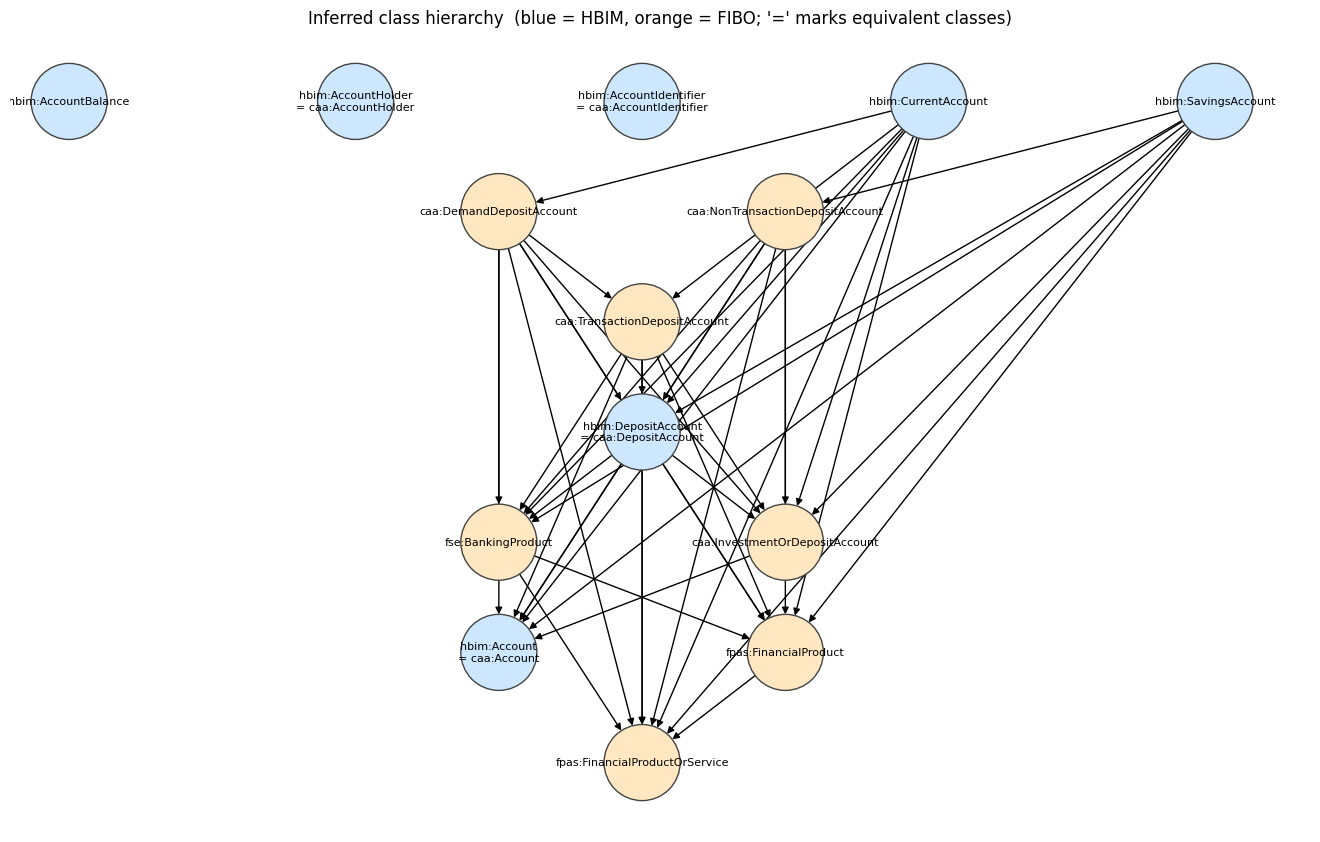

In [6]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict

# Subclass edges (child -> parent) among named reportable classes.
DG = nx.DiGraph()
DG.add_nodes_from(q(inferred, c) for c in hbim_classes)
for s, o in inferred.subject_objects(RDFS.subClassOf):
    if is_reportable(s) and is_reportable(o) and s != o:
        DG.add_edge(q(inferred, s), q(inferred, o))

# equivalentClass makes A<->B mutually subClassOf -> cycles. Condense each
# strongly-connected (equivalent) group into one node so the layout is a DAG.
cond = nx.condensation(DG)              # DAG of SCCs; node attr 'members'
def label(scc):
    members = sorted(cond.nodes[scc]["members"])
    hb = [m for m in members if m.startswith("hbim:")]
    return "\n= ".join(hb + [m for m in members if not m.startswith("hbim:")])

# layered positions: superclasses on top, subclasses below
depth = {}
for d, layer in enumerate(nx.topological_generations(cond)):
    for n in layer:
        depth[n] = d
maxd = max(depth.values()) if depth else 0
bylvl = defaultdict(list)
for n, d in depth.items():
    bylvl[d].append(n)
pos = {}
for d, nodes in bylvl.items():
    for i, n in enumerate(sorted(nodes)):
        pos[n] = (i - (len(nodes) - 1) / 2, maxd - d)

labels = {n: label(n) for n in cond.nodes}
colors = ["#cde7ff" if "hbim:" in labels[n] else "#ffe7c2" for n in cond.nodes]
plt.figure(figsize=(13, 8))
nx.draw(cond, pos, labels=labels, node_color=colors, node_size=3000,
        font_size=8, edgecolors="#444", arrows=True, arrowstyle="-|>")
plt.title("Inferred class hierarchy  (blue = HBIM, orange = FIBO; '=' marks equivalent classes)")
plt.axis("off"); plt.tight_layout(); plt.show()

## C) How FIBO reasoning improves HBIM

### 1. Enrich HBIM with inferred classifications

In [7]:
ca = HBIM["CurrentAccount"]
if (ca, RDFS.subClassOf, FPAS.FinancialProduct) in inferred:
    print(f"FIBO proves {q(inferred, ca)} is a fpas:FinancialProduct,")
    print("although HBIM only stated it was a kind of demand-deposit account.")
    print("=> Add it to the HBIM Product subject area and reuse FIBO product governance.")

FIBO proves hbim:CurrentAccount is a fpas:FinancialProduct,
although HBIM only stated it was a kind of demand-deposit account.
=> Add it to the HBIM Product subject area and reuse FIBO product governance.


### 2. Completeness rules from inherited FIBO restrictions

In [8]:
def inherited_restrictions(g, cls):
    found = {}
    for sup in set(g.objects(cls, RDFS.subClassOf)) | {cls}:
        for r in g.objects(sup, RDFS.subClassOf):
            if (r, RDF.type, OWL.Restriction) in g:
                prop = next(g.objects(r, OWL.onProperty), None)
                filler = next(g.objects(r, OWL.someValuesFrom), None)
                if prop is not None and filler is not None and is_reportable(filler):
                    # prefer the FIBO filler over its HBIM twin
                    if prop not in found or not str(filler).startswith(str(HBIM)):
                        found[prop] = filler
    return found

rows = [{"every": q(inferred, ca), "must link via": q(inferred, p), "to": q(inferred, f)}
        for p, f in inherited_restrictions(inferred, ca).items()]
print("=> Turn these into HBIM data-quality checks (mandatory attributes).")
pd.DataFrame(rows)

=> Turn these into HBIM data-quality checks (mandatory attributes).


,every,must link via,to
0,hbim:CurrentAccount,rel:isHeldBy,caa:AccountHolder
1,hbim:CurrentAccount,cmns-org:isProvidedBy,fse:DepositoryInstitution
2,hbim:CurrentAccount,cmns-id:isIdentifiedBy,caa:AccountIdentifier


### 3. Equivalent-class bridges keep HBIM and FIBO in lock-step

In [9]:
rows = [{"hbim": q(inferred, s), "owl:equivalentClass": q(inferred, o)}
        for s, o in inferred.subject_objects(OWL.equivalentClass)
        if str(s).startswith(str(HBIM)) and is_reportable(o)
        and s != o and not str(o).startswith(str(HBIM))]
pd.DataFrame(sorted(rows, key=lambda r: r["hbim"]))

,hbim,owl:equivalentClass
0,hbim:Account,caa:Account
1,hbim:AccountHolder,caa:AccountHolder
2,hbim:AccountIdentifier,caa:AccountIdentifier
3,hbim:DepositAccount,caa:DepositAccount


## C.4) Consistency check — FIBO disjointness validates HBIM

We inject a modelling error: map the (transactional) *Current Account* **also**
to `NonTransactionDepositAccount`. FIBO declares the two disjoint, so the sample
individual is forced into two disjoint classes — a clash the reasoner detects.

In [10]:
bad = bind_all(Graph()); bad.bind("skos", SKOS)
for t in asserted:
    bad.add(t)
bad.add((ca, RDFS.subClassOf, CAA.NonTransactionDepositAccount))   # the mistake
DeductiveClosure(OWLRL_Semantics).expand(bad)

def disjoint_clashes(g):
    clashes = []
    pairs = {frozenset(p) for p in g.subject_objects(OWL.disjointWith)}
    for pair in pairs:
        a, b = tuple(pair)
        ma = set(g.subjects(RDF.type, a)) | set(g.subjects(RDFS.subClassOf, a))
        mb = set(g.subjects(RDF.type, b)) | set(g.subjects(RDFS.subClassOf, b))
        for n in (ma & mb):
            if n in (a, b) or n == OWL.Nothing or isinstance(n, BNode):
                continue
            clashes.append((n, a, b))
    return clashes

clashes = disjoint_clashes(bad)
if clashes:
    print("[INCONSISTENT] FIBO reasoning rejected the bad mapping:")
    for n, a, b in clashes:
        print(f"  {q(bad, n)} forced into disjoint {q(bad, a)} and {q(bad, b)}")
    print("\n=> HBIM mapping error caught automatically: 'Current Account' is a")
    print("   transaction account and must NOT map to NonTransactionDepositAccount.")
else:
    print("no clash detected")

[INCONSISTENT] FIBO reasoning rejected the bad mapping:
  hbim:account-GB29NWBK60161331926819 forced into disjoint caa:NonTransactionDepositAccount and caa:TransactionDepositAccount
  hbim:CurrentAccount forced into disjoint caa:NonTransactionDepositAccount and caa:TransactionDepositAccount

=> HBIM mapping error caught automatically: 'Current Account' is a
   transaction account and must NOT map to NonTransactionDepositAccount.


## Persist the inferred graph

In [11]:
inferred.serialize(destination=HBIM_INFERRED_TTL, format="turtle")
print("[written]", HBIM_INFERRED_TTL)

[written] C:\Users\marci\OneDrive\DEV\EDU\AIML\Graph ML\Ontology Engineering\Ontology Repository\FIBO\Ontology Mapping\output\hbim_account_inferred.ttl
